# Text Classification with Bag of Words + Scikit-Learn
### Dataset: `sentiment_data.csv` — 241,900 comments, 3 Sentiment Classes
| Label | Meaning |
|---|---|
| 0 | Negative |
| 1 | Neutral |
| 2 | Positive |

---
**What you will learn:**
1. Load & explore real text data
2. **Clean & preprocess raw text** (NEW)
3. Convert text → numbers using **Bag of Words (BOW)**
4. Train 5 ML algorithms with their key parameters
5. Evaluate models using **5-Fold Cross Validation**
6. Measure **prediction speed** (inference time) of each model
7. Pick the best model for production

---
###  What's in our raw data? (Noise we need to fix)
| Problem | Example from data | Fix |
|---|---|---|
| Contractions | `don't`, `it's`, `i've` | Expand → `do not`, `it is` |
| Punctuation / symbols | `"…`, `'`, `!`, `@` | Remove |
| Non-English text | Malayalam script characters | Remove non-ASCII |
| Repeated characters | `reallly`, `qualiity` | Normalise → `really`, `quality` |
| Numbers | `100`, `2024` | Remove (usually no sentiment) |
| Extra whitespace | multiple spaces | Strip & squeeze |
| Very short comments | `yes`, `ok` | Drop (no useful signal) |

##  Import Libraries
> We bring in everything we need upfront. Good practice for notebooks.

In [21]:
import pandas as pd
import numpy as np
import re
import time
import warnings
warnings.filterwarnings('ignore')

# --- Text Preprocessing ---
from sklearn.feature_extraction.text import CountVectorizer       # Bag of Words

# --- Train/Test Split & Cross Validation ---
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# --- ML Algorithms ---
from sklearn.naive_bayes      import MultinomialNB
from sklearn.linear_model     import LogisticRegression, SGDClassifier
from sklearn.svm              import LinearSVC
from sklearn.ensemble         import RandomForestClassifier

# --- Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


## Load the Data
> We load the CSV, drop the unnamed index column, and take a first look at the data.

In [22]:
# Load the dataset
df = pd.read_csv('sentiment_data.csv', index_col=0)


print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (100, 2)

First 5 rows:


,Comment,Sentiment
114557,agenda india super power trillion dollar econo...,0
239696,one jerk put even lights modi would india,1
173103,looks like nothings going right china trump mo...,2
117975,modi bad small businessmen given free rein ias...,0
187024,press conference questions modi answer,1


In [23]:
# --- Check for nulls ---
print("Null values per column:")
print(df.isnull().sum())

# --- Drop rows with missing comments ---
df.dropna(subset=['Comment'], inplace=True)
df['Comment'] = df['Comment'].astype(str)

print(f"\nClean dataset size: {len(df):,} rows")

Null values per column:
Comment      0
Sentiment    0
dtype: int64

Clean dataset size: 100 rows



## Explore the Data
> Always understand your data before modelling. Check class balance!

Class Distribution:
  0 (Negative):      31  (31.0%)
  1 (Neutral):      32  (32.0%)
  2 (Positive):      37  (37.0%)


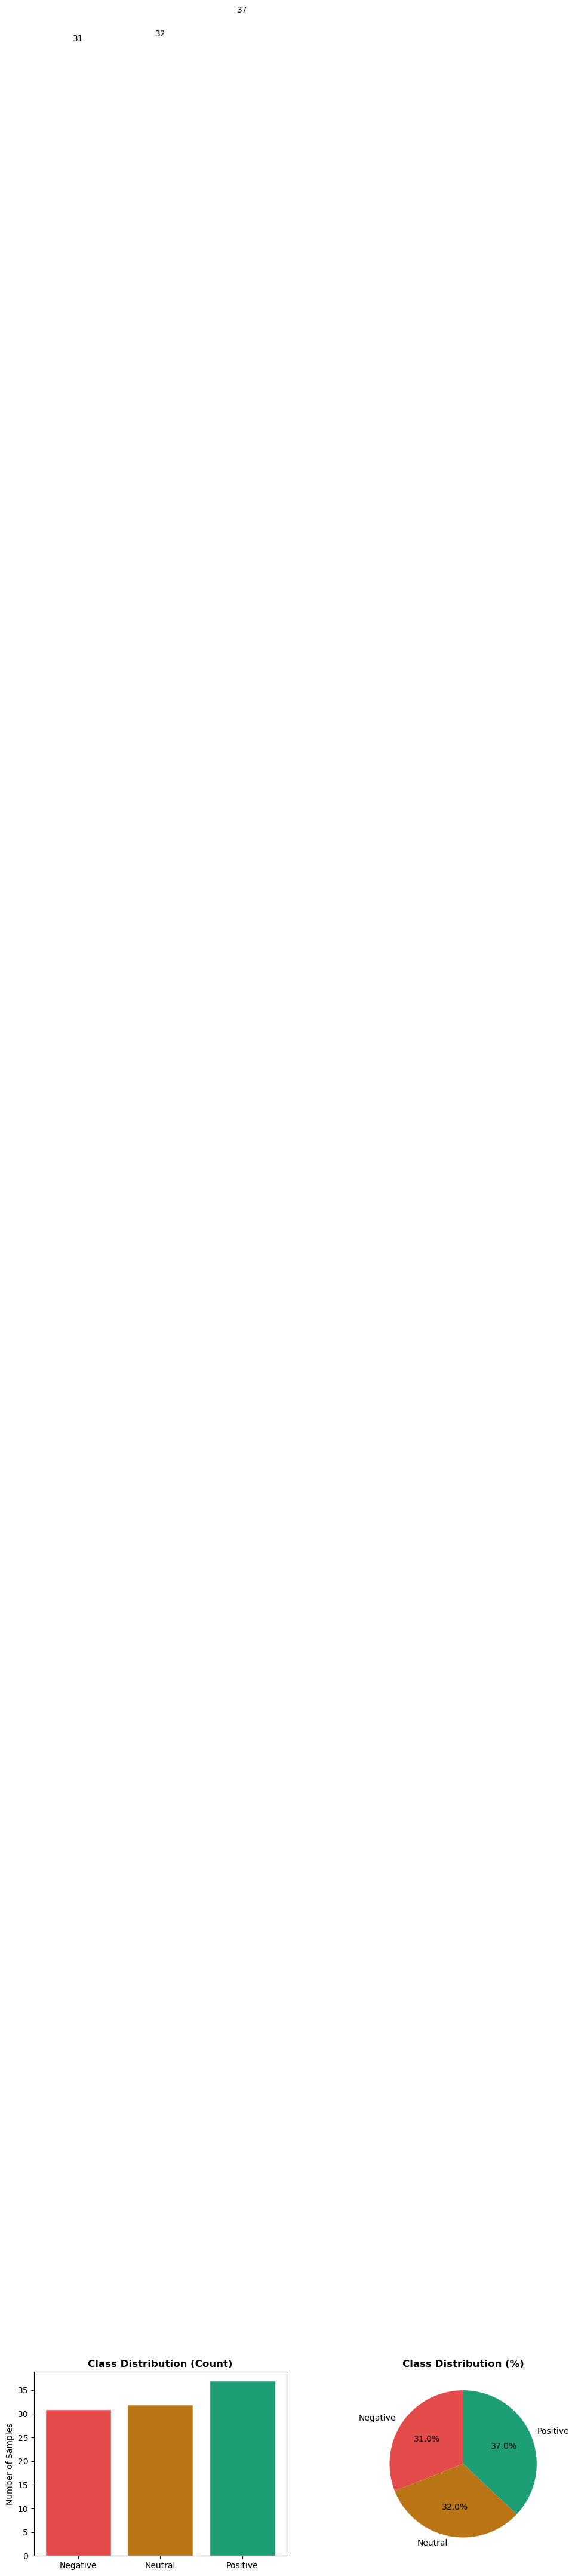


Comment Word Count Statistics:
count    100.0
mean      14.8
std       12.7
min        2.0
25%        7.0
50%       13.0
75%       18.0
max      101.0
Name: comment_length, dtype: float64


In [24]:
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# Class distribution
class_counts = df['Sentiment'].value_counts().sort_index()
print("Class Distribution:")
for label, count in class_counts.items():
    pct = count / len(df) * 100
    print(f"  {label} ({label_names[label]}): {count:>7,}  ({pct:.1f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#E24B4A', '#BA7517', '#1D9E75']
axes[0].bar([label_names[i] for i in range(3)], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values,
            labels=[label_names[i] for i in range(3)],
            colors=colors,
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.show()

# Comment length analysis
df['comment_length'] = df['Comment'].apply(lambda x: len(x.split()))
print("\nComment Word Count Statistics:")
print(df['comment_length'].describe().round(1))

## Train / Test Split  *(Split BEFORE cleaning!)*
> **Golden Rule:** Split the data FIRST, clean AFTER.
>
> Why? Because even cleaning steps (like learning which words to expand)
> must be based only on training data. Test data must stay completely untouched
> until final evaluation.
>
> `stratify=y` ensures each split has the same class % as the full dataset.

In [25]:
X_raw = df['Comment'].values   # Raw text
y     = df['Sentiment'].values  # Labels (0, 1, 2)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size    = 0.2,        # 80% train, 20% test
    random_state = 42,         # reproducible split
    stratify     = y           # maintain class ratios in both splits
)

print(f"Training samples : {len(X_train_raw):>7,}")
print(f"Test samples     : {len(X_test_raw):>7,}")

Training samples :      80
Test samples     :      20


---
## Text Cleaning  

> Raw text is full of noise — punctuation, emojis, repeated letters, non-English
> characters, numbers — that add nothing to sentiment prediction.
> Cleaning improves the signal the model learns from.
>
> **Each cleaning step is a separate function** so students can see exactly
> what each one does and turn individual steps on/off.

### Why does the ORDER of cleaning steps matter?
> **Contractions first** — expand `don't` → `do not` BEFORE removing apostrophes.
> If you remove punctuation first, `don't` becomes `dont` and the contraction
> is lost forever. Order matters!

In [26]:
# =============================================================
# STEP 1: Contraction Expansion
# -------------------------------------------------------------
# WHY: "don't" and "do not" should be treated the same.
#      BOW treats them as completely different words otherwise.
# HOW: Simple dictionary lookup and replace.
# NOTE: Must happen BEFORE punctuation removal!
# =============================================================

CONTRACTIONS = {
    "don't":"do not", "doesn't":"does not", "didn't":"did not",
    "isn't":"is not", "aren't":"are not", "wasn't":"was not",
    "weren't":"were not", "haven't":"have not", "hasn't":"has not",
    "hadn't":"had not", "won't":"will not", "wouldn't":"would not",
    "can't":"cannot", "couldn't":"could not", "shouldn't":"should not",
    "mustn't":"must not", "needn't":"need not", "i'm":"i am",
    "i've":"i have", "i'll":"i will", "i'd":"i would",
    "it's":"it is", "it'd":"it would", "it'll":"it will",
    "that's":"that is", "that'd":"that would", "that'll":"that will",
    "they're":"they are", "they've":"they have", "they'll":"they will",
    "they'd":"they would", "we're":"we are", "we've":"we have",
    "we'll":"we will", "we'd":"we would", "you're":"you are",
    "you've":"you have", "you'll":"you will", "you'd":"you would",
    "he's":"he is", "he'd":"he would", "he'll":"he will",
    "she's":"she is", "she'd":"she would", "she'll":"she will",
    "there's":"there is", "there're":"there are",
    "who's":"who is", "who'd":"who would", "who'll":"who will",
    "what's":"what is", "what're":"what are", "what'll":"what will",
    "let's":"let us", "y'all":"you all", "gonna":"going to",
    "wanna":"want to", "gotta":"got to", "kinda":"kind of",
    "sorta":"sort of", "dunno":"do not know", "ain't":"is not",
    "'ve":" have", "'re":" are", "'ll":" will", "'d":" would"
}

def expand_contractions(text):
    # Sort by length descending so longer contractions match first
    for contraction, expansion in sorted(CONTRACTIONS.items(),
                                          key=lambda x: len(x[0]), reverse=True):
        text = text.replace(contraction, expansion)
    return text


# =============================================================
# STEP 2: Remove URLs
# -------------------------------------------------------------
# WHY: URLs like "https://youtube.com" add no sentiment signal.
# HOW: Regex pattern matches http/https/www links.
# =============================================================

def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)


# =============================================================
# STEP 3: Remove Non-ASCII Characters
# -------------------------------------------------------------
# WHY: Our data has Malayalam script (Kerala language), Chinese,
#      Arabic etc. BOW on English models can't use these.
#      Example: "liquid nitrogen ഇതുവരെ തീർന്നില്ലേ" → "liquid nitrogen"
# HOW: Keep only characters in ASCII range (0-127).
# NOTE: If your task NEEDS multilingual support, skip this step
#       and use a multilingual model instead.
# =============================================================

def remove_non_ascii(text):
    return text.encode('ascii', errors='ignore').decode('ascii')


# =============================================================
# STEP 4: Remove Punctuation & Special Characters
# -------------------------------------------------------------
# WHY: Characters like !@#$%^&*()"'…— carry minimal ML signal
#      for BOW. They fragment tokens and pollute vocabulary.
# HOW: Keep only letters and spaces using regex.
# NOTE: Some NLP tasks DO want punctuation (e.g., !!! shows emotion).
#       For BOW classification, removing is usually better.
# =============================================================

def remove_punctuation(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)


# =============================================================
# STEP 5: Normalise Repeated Characters
# -------------------------------------------------------------
# WHY: "reallly" and "really" should be the same word.
#      "qualiity" → "quality". Typos and emphasis cause vocabulary
#      explosion and sparse, unhelpful features.
# HOW: Collapse any character repeated 3+ times to just 2.
#      We keep 2 (not 1) because "oo" in "good" is valid.
# =============================================================

def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)


# =============================================================
# STEP 6: Lowercase
# -------------------------------------------------------------
# WHY: "Apple", "apple", "APPLE" should all map to the same token.
#      Without this, BOW treats them as 3 different features.
# NOTE: We do this AFTER contraction expansion so the lookup
#       table works correctly on original casing.
# =============================================================

def to_lowercase(text):
    return text.lower()


# =============================================================
# STEP 7: Remove Extra Whitespace
# -------------------------------------------------------------
# WHY: Cleaning steps above leave behind multiple spaces.
#      Tokeniser splits on whitespace, so clean it up.
# =============================================================

def remove_extra_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()


# =============================================================
# MASTER CLEANING FUNCTION
# Apply all steps in the correct order.
# =============================================================

def clean_text(text):
    text = str(text)                      # ensure string
    text = to_lowercase(text)             # lowercase first for contraction lookup
    text = expand_contractions(text)      # don't → do not  (BEFORE punctuation removal)
    text = remove_urls(text)              # remove http links
    text = remove_non_ascii(text)         # remove Malayalam, Chinese, etc.
    text = remove_punctuation(text)       # remove !@#"'… etc.
    text = normalize_repeated_chars(text) # reallly → really
    text = remove_extra_whitespace(text)  # squeeze multiple spaces
    return text


print("All cleaning functions defined!")
print("\nFunction order:")
print("  1. to_lowercase")
print("  2. expand_contractions  ← must be before punctuation removal")
print("  3. remove_urls")
print("  4. remove_non_ascii")
print("  5. remove_punctuation")
print("  6. normalize_repeated_chars")
print("  7. remove_extra_whitespace")

All cleaning functions defined!

Function order:
  1. to_lowercase
  2. expand_contractions  ← must be before punctuation removal
  3. remove_urls
  4. remove_non_ascii
  5. remove_punctuation
  6. normalize_repeated_chars
  7. remove_extra_whitespace


In [27]:
# =============================================================
# Apply cleaning to Train and Test separately
# IMPORTANT: Same function applied to both — no fitting here.
# Rule-based cleaning (regex) does NOT learn from data,
# so it's safe to apply identically to train and test.
# =============================================================

print("Cleaning training data...", end=' ')
t0 = time.time()
X_train_clean = np.array([clean_text(t) for t in X_train_raw])
print(f"done ({time.time()-t0:.1f}s)")

print("Cleaning test data...",     end=' ')
t0 = time.time()
X_test_clean  = np.array([clean_text(t) for t in X_test_raw])
print(f"done ({time.time()-t0:.1f}s)")


# =============================================================
# STEP 8: Remove Very Short Comments
# -------------------------------------------------------------
# WHY: After cleaning, some comments become 1-2 words — not
#      enough signal for classification. Drop them.
# THRESHOLD: 3 words minimum. Adjust based on your data.
# NOTE: Only filter TRAINING data. Keep all test samples for
#       fair evaluation.
# =============================================================

MIN_WORDS = 3

train_lengths = np.array([len(t.split()) for t in X_train_clean])
train_mask    = train_lengths >= MIN_WORDS

removed = (~train_mask).sum()
X_train_clean = X_train_clean[train_mask]
y_train       = y_train[train_mask]

print(f"\nShort comment filter (< {MIN_WORDS} words):")
print(f"  Removed from train : {removed:,}")
print(f"  Final train size   : {len(X_train_clean):,}")
print(f"  Test size          : {len(X_test_clean):,}  (unchanged — never filter test)")


# =============================================================
# Compare vocabulary size: raw vs cleaned
# =============================================================

raw_vocab   = set(' '.join(X_train_raw).split())
clean_vocab = set(' '.join(X_train_clean).split())

print(f"\nVocabulary size BEFORE cleaning : {len(raw_vocab):,} unique tokens")
print(f"Vocabulary size AFTER  cleaning : {len(clean_vocab):,} unique tokens")
print(f"Reduction: {len(raw_vocab) - len(clean_vocab):,} noisy tokens removed")

Cleaning training data... done (0.1s)
Cleaning test data... done (0.0s)

Short comment filter (< 3 words):
  Removed from train : 2
  Final train size   : 78
  Test size          : 20  (unchanged — never filter test)

Vocabulary size BEFORE cleaning : 857 unique tokens
Vocabulary size AFTER  cleaning : 841 unique tokens
Reduction: 16 noisy tokens removed


---
## Bag of Words (BOW) Preprocessing
> Now that text is clean, we convert it to numbers.
> **What is BOW?** Each document becomes a vector of word counts.
>
> Example: `"do not like high fees"` → `{do:1, not:1, like:1, high:1, fees:1}`
>
> **CRITICAL RULE:** `fit_transform` on TRAIN only. `transform` on TEST only.

In [28]:
# =============================================================
# CountVectorizer Parameters — Explained
# =============================================================
# max_features  : Keep only top N words by frequency.
#                 30000-50000 is good for large datasets.
#
# stop_words    : Remove common words (the, is, and).
#                 Note: We already expanded contractions,
#                 so "do not" now correctly gets "not" removed
#                 by stop_words — vs "don't" which wouldn't match.
#
# ngram_range   : (1,2) captures both single words AND pairs.
#                 "not good" as a bigram catches negation!
#
# min_df        : Ignore words in fewer than N docs.
#                 Cleans out rare one-off tokens.
# =============================================================

vectorizer = CountVectorizer(
    max_features = 30000,
    stop_words   = 'english',
    ngram_range  = (1, 2),
    min_df       = 2,
    lowercase    = True      # safety net (already lowercased)
)

# fit on TRAIN clean text → learn vocabulary
X_train = vectorizer.fit_transform(X_train_clean)

# transform TEST using the vocabulary learned above
X_test  = vectorizer.transform(X_test_clean)

print(f"Train BOW matrix : {X_train.shape}")
print(f"Test  BOW matrix : {X_test.shape}")
print(f"Vocabulary size  : {len(vectorizer.vocabulary_):,}")
sparsity = (1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100
print(f"Matrix sparsity  : {sparsity:.1f}%  (most cells are 0 — that's normal for BOW)")

print("\nSample features from vocabulary:")
sample_features = list(vectorizer.vocabulary_.keys())[:20]
print(sample_features)

Train BOW matrix : (78, 121)
Test  BOW matrix : (20, 121)
Vocabulary size  : 121
Matrix sparsity  : 96.2%  (most cells are 0 — that's normal for BOW)

Sample features from vocabulary:
['brilliant', 'matter', 'new', 'program', 'perfect', 'day', 'later', 'happy', 'world', 'modi', 'interview', 'say', 'asat', 'modis', 'surgical', 'strike', 'house', 'surgical strike', 'tonight', 'usa']


##  Define All Algorithms with Parameters
> Each algorithm has key parameters that control its behaviour.
> Read the comments carefully — this is what to tune first when accuracy is low.

In [29]:
# =============================================================
# ALGORITHM 1: Multinomial Naive Bayes
# HOW IT WORKS: Uses probability. P(Positive | word) based on
#               how often each word appears in each class.
# WHEN TO USE : First model to try for text. Fast, needs less
#               data, works well with sparse BOW.
# WEAKNESS    : Assumes words are independent (often not true).
#
# KEY PARAMS:
#   alpha : Laplace smoothing. Avoids zero probability for
#           unseen words. Default 1.0. Try 0.1 or 0.5 if
#           accuracy is low — more smoothing = simpler model.
# =============================================================
nb_model = MultinomialNB(alpha=1.0)


# =============================================================
# ALGORITHM 2: Logistic Regression
# HOW IT WORKS: Finds a linear decision boundary. Gives
#               probability estimates per class (0.0 to 1.0).
# WHEN TO USE : When you need probability scores, not just
#               labels. Great all-round text classifier.
#
# KEY PARAMS:
#   C        : Inverse regularisation strength.
#              Low  C = simpler model (prevents overfitting).
#              High C = fits data tightly (can overfit).
#              Try: 0.01, 0.1, 1.0, 10.0
#   max_iter : Increase if you see ConvergenceWarning.
#   solver   : 'lbfgs' is best for multiclass problems.
# =============================================================
lr_model = LogisticRegression(
    C            = 1.0,
    max_iter     = 1000,
    solver       = 'lbfgs',
    multi_class  = 'auto',
    random_state = 42
)


# =============================================================
# ALGORITHM 3: Linear SVM
# HOW IT WORKS: Finds the widest possible margin between
#               classes. Gold standard for text classification.
# WHEN TO USE : When accuracy is the top priority.
#               High-dimensional sparse data (like BOW).
# WEAKNESS    : No probability output.
#
# KEY PARAMS:
#   C        : Margin vs misclassification tradeoff.
#              Same logic as Logistic Regression's C.
#   max_iter : Increase if model issues convergence warning.
# =============================================================
svm_model = LinearSVC(
    C        = 1.0,
    max_iter = 2000
)


# =============================================================
# ALGORITHM 4: SGD Classifier
# HOW IT WORKS: Online learning — one sample at a time using
#               gradient descent. Very memory efficient.
# WHEN TO USE : Millions of docs. Data too large for RAM.
#               Streaming/real-time incoming data.
#
# KEY PARAMS:
#   loss     : 'modified_huber' gives probabilities + noise robustness.
#              'hinge' = mimics Linear SVM. 'log_loss' = mimics LR.
#   alpha    : Regularisation. Increase if model overfits.
#   max_iter : Epochs (passes over full training data).
# =============================================================
sgd_model = SGDClassifier(
    loss         = 'modified_huber',
    alpha        = 1e-4,
    max_iter     = 100,
    random_state = 42
)


# =============================================================
# ALGORITHM 5: Random Forest
# HOW IT WORKS: Many decision trees on random data subsets.
#               Each tree votes — majority wins.
# WHEN TO USE : Mixed features (text + numeric). Non-linear
#               patterns. Feature importance analysis.
# WEAKNESS    : Slow on high-dim sparse BOW. Memory heavy.
#
# KEY PARAMS:
#   n_estimators     : Number of trees. More = better (to a point).
#   max_depth        : None = grow until pure. Limit to avoid overfit.
#   min_samples_leaf : Higher = smoother, less overfit.
#   n_jobs           : -1 = use all CPU cores.
# =============================================================
rf_model = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = None,
    min_samples_leaf = 1,
    random_state     = 42,
    n_jobs           = -1
)

print(" All 5 models defined!")

 All 5 models defined!


---
##  5-Fold Stratified Cross Validation
> **Why CV instead of a single split?**
> A single 80/20 split is a lottery — you might get lucky or unlucky.
> CV runs 5 different splits and averages them → much more reliable estimate.
>
> **Stratified** = each fold preserves the class balance (Neg/Neu/Pos %).

In [30]:
models = {
    'Naive Bayes'         : nb_model,
    'Logistic Regression' : lr_model,
    'Linear SVM'          : svm_model,
    'SGD Classifier'      : sgd_model,
    'Random Forest'       : rf_model
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

print(f"{'Model':<25} {'F1':>7} {'F2':>7} {'F3':>7} {'F4':>7} {'F5':>7}  {'Mean':>7} {'Std':>7}")
print("-" * 78)

for name, model in models.items():
    t0     = time.time()
    scores = cross_val_score(
        model, X_train, y_train,
        cv      = skf,
        scoring = 'accuracy',
        n_jobs  = -1
    )
    elapsed = time.time() - t0
    cv_results[name] = scores
    print(f"{name:<25} {scores[0]:>7.4f} {scores[1]:>7.4f} {scores[2]:>7.4f} {scores[3]:>7.4f} {scores[4]:>7.4f}  {scores.mean():>7.4f} {scores.std():>7.4f}  [{elapsed:.1f}s]")

Model                          F1      F2      F3      F4      F5     Mean     Std
------------------------------------------------------------------------------
Naive Bayes                0.2500  0.4375  0.6250  0.6000  0.2667   0.4358  0.1587  [4.1s]
Logistic Regression        0.4375  0.3125  0.6250  0.5333  0.3333   0.4483  0.1185  [2.9s]
Linear SVM                 0.5000  0.2500  0.4375  0.5333  0.2667   0.3975  0.1178  [0.1s]
SGD Classifier             0.3125  0.5625  0.5000  0.5333  0.3333   0.4483  0.1045  [0.0s]
Random Forest              0.3750  0.3125  0.3750  0.2667  0.4667   0.3592  0.0675  [0.6s]


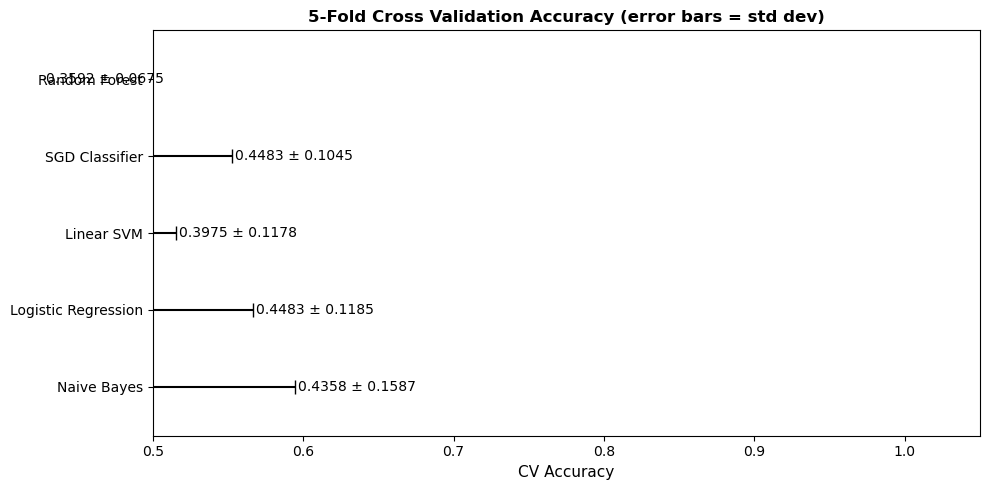


 Best CV model: Logistic Regression (mean = 0.4483)


In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors = ['#378ADD', '#1D9E75', '#534AB7', '#D85A30', '#D4537E']

bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor='white',
               capsize=5, alpha=0.9)

for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f} ± {std:.4f}', va='center', fontsize=10)

ax.set_xlim(0.5, 1.05)
ax.set_xlabel('CV Accuracy', fontsize=11)
ax.set_title('5-Fold Cross Validation Accuracy (error bars = std dev)', fontweight='bold')
plt.tight_layout()
plt.show()

best_cv = max(cv_results, key=lambda n: cv_results[n].mean())
print(f"\n Best CV model: {best_cv} (mean = {cv_results[best_cv].mean():.4f})")


## Train All Models on Full Training Set
> CV tells us which models work well. Now train each on the **full** training set.
> More data = better final model.
> Save each trained model in a dict — pick any one later by name.

In [32]:
trained_models = {}
train_times    = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    t1 = time.perf_counter()
    trained_models[name] = model
    train_times[name]    = t1 - t0
    print(f"✓  ({t1-t0:.2f}s)")

print(" All models trained and saved in `trained_models` dict")
print("   Access any model:  trained_models['Linear SVM']")

Training Naive Bayes... ✓  (0.01s)
Training Logistic Regression... ✓  (0.01s)
Training Linear SVM... ✓  (0.00s)
Training SGD Classifier... ✓  (0.01s)
Training Random Forest... ✓  (0.34s)
 All models trained and saved in `trained_models` dict
   Access any model:  trained_models['Linear SVM']



## Inference Time Benchmarking
> In production, **how fast** a model predicts matters as much as accuracy.
> We run 50 repetitions and average — a single run has OS scheduling noise.
>
> `time.perf_counter()` is the most precise timer in Python.

In [35]:
timing_results = {}
N_RUNS = 50

print(f"Benchmarking on {X_test.shape[0]:,} test samples × {N_RUNS} runs...\n")
print(f"{'Model':<25} {'Avg (ms)':>10} {'Per doc (µs)':>14} {'% of slowest':>14}")
print("-" * 68)

for name, model in trained_models.items():
    times = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        _  = model.predict(X_test)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    avg_ms  = np.mean(times) * 1000
    per_doc = np.mean(times) / X_test.shape[0] * 1_000_000

    timing_results[name] = {'avg_ms': avg_ms, 'per_doc': per_doc}

slowest_ms = max(timing_results[n]['avg_ms'] for n in timing_results)

for name, res in timing_results.items():
    pct = res['avg_ms'] / slowest_ms * 100
    print(f"{name:<25} {res['avg_ms']:>10.2f} {res['per_doc']:>14.2f} {pct:>14.1f}%")

Benchmarking on 20 test samples × 50 runs...

Model                       Avg (ms)   Per doc (µs)   % of slowest
--------------------------------------------------------------------
Naive Bayes                     0.08           4.08            0.3%
Logistic Regression             0.07           3.67            0.3%
Linear SVM                      0.09           4.45            0.3%
SGD Classifier                  0.07           3.38            0.3%
Random Forest                  26.93        1346.55          100.0%


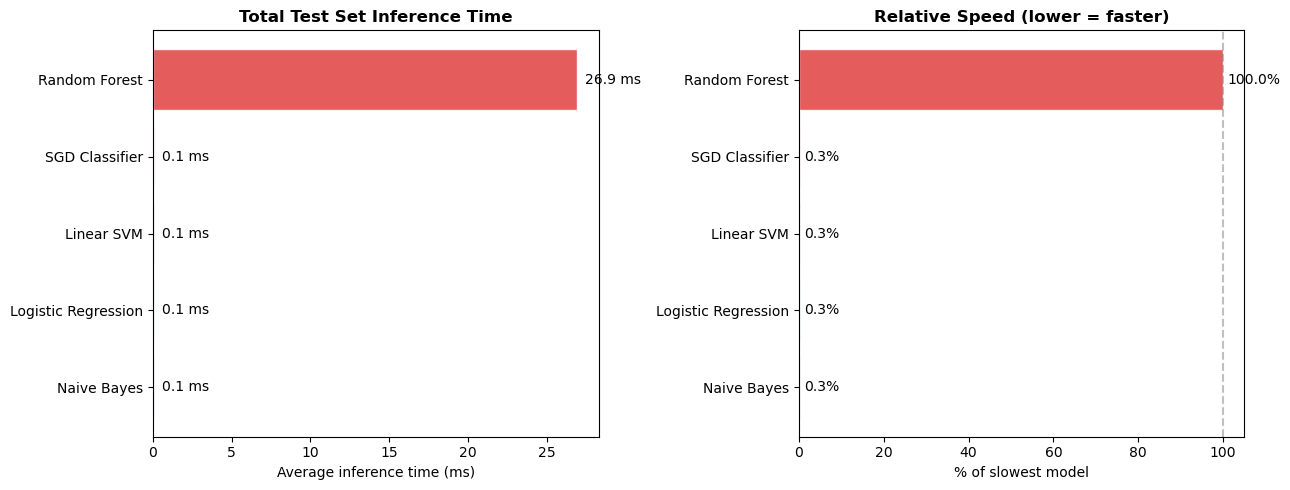


 Fastest: SGD Classifier
 Slowest: Random Forest
   SGD Classifier is 399× faster than Random Forest


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names_t  = list(timing_results.keys())
avg_ms   = [timing_results[n]['avg_ms']  for n in names_t]
pcts     = [t / slowest_ms * 100 for t in avg_ms]
colors   = ['#378ADD', '#1D9E75', '#534AB7', '#D85A30', '#E24B4A']

axes[0].barh(names_t, avg_ms, color=colors, edgecolor='white', alpha=0.9)
for i, v in enumerate(avg_ms):
    axes[0].text(v + 0.5, i, f'{v:.1f} ms', va='center', fontsize=10)
axes[0].set_xlabel('Average inference time (ms)')
axes[0].set_title('Total Test Set Inference Time', fontweight='bold')

axes[1].barh(names_t, pcts, color=colors, edgecolor='white', alpha=0.9)
axes[1].axvline(x=100, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(pcts):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)
axes[1].set_xlabel('% of slowest model')
axes[1].set_title('Relative Speed (lower = faster)', fontweight='bold')

plt.tight_layout()
plt.show()

fastest      = min(timing_results, key=lambda n: timing_results[n]['avg_ms'])
slowest_name = max(timing_results, key=lambda n: timing_results[n]['avg_ms'])
speedup = timing_results[slowest_name]['avg_ms'] / timing_results[fastest]['avg_ms']
print(f"\n Fastest: {fastest}")
print(f" Slowest: {slowest_name}")
print(f"   {fastest} is {speedup:.0f}× faster than {slowest_name}")


## Final Test Set Evaluation
> Now we evaluate on the held-out test set — never seen by the model.
> This is the true measure of real-world performance.

In [38]:
target_names = ['Negative', 'Neutral', 'Positive']
test_results = {}

for name, model in trained_models.items():
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    test_results[name] = {'acc': acc, 'preds': preds}

    print(f"\n{'='*60}")
    print(f" {name}  |  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print('='*60)
    print(classification_report(y_test, preds, target_names=target_names))


 Naive Bayes  |  Test Accuracy: 0.3500 (35.00%)
              precision    recall  f1-score   support

    Negative       0.50      0.17      0.25         6
     Neutral       0.27      0.43      0.33         7
    Positive       0.43      0.43      0.43         7

    accuracy                           0.35        20
   macro avg       0.40      0.34      0.34        20
weighted avg       0.40      0.35      0.34        20


 Logistic Regression  |  Test Accuracy: 0.3000 (30.00%)
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         6
     Neutral       0.25      0.43      0.32         7
    Positive       0.50      0.43      0.46         7

    accuracy                           0.30        20
   macro avg       0.25      0.29      0.26        20
weighted avg       0.26      0.30      0.27        20


 Linear SVM  |  Test Accuracy: 0.4500 (45.00%)
              precision    recall  f1-score   support

    Negative       0.00      

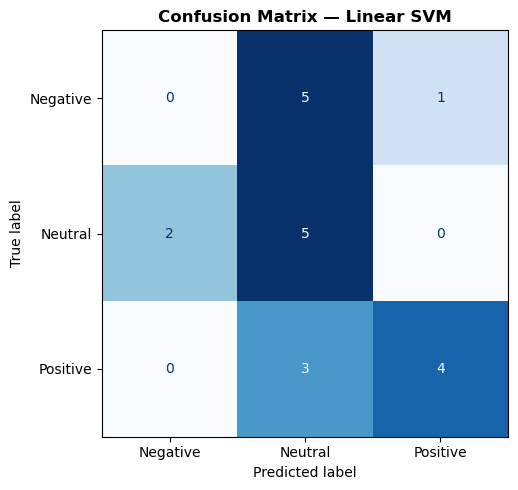


How to read this:
  Rows = Actual class    Columns = Predicted class
  Diagonal = correct predictions
  Off-diagonal = errors (what got confused with what)


In [39]:
best_test_model = max(test_results, key=lambda n: test_results[n]['acc'])
best_preds      = test_results[best_test_model]['preds']

fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_test_model}', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nHow to read this:")
print("  Rows = Actual class    Columns = Predicted class")
print("  Diagonal = correct predictions")
print("  Off-diagonal = errors (what got confused with what)")

## Final Comparison Dashboard



📋 FINAL COMPARISON TABLE
                    CV Mean Acc  CV Std Test Accuracy Train Time (s) Infer Time (ms) Per Doc (µs)
Model                                                                                            
Naive Bayes              0.4358  0.1587        0.3500          0.01s           0.1ms        4.1µs
Logistic Regression      0.4483  0.1185        0.3000          0.01s           0.1ms        3.7µs
Linear SVM               0.3975  0.1178        0.4500          0.00s           0.1ms        4.5µs
SGD Classifier           0.4483  0.1045        0.4000          0.01s           0.1ms        3.4µs
Random Forest            0.3592  0.0675        0.3500          0.34s          26.9ms     1346.6µs


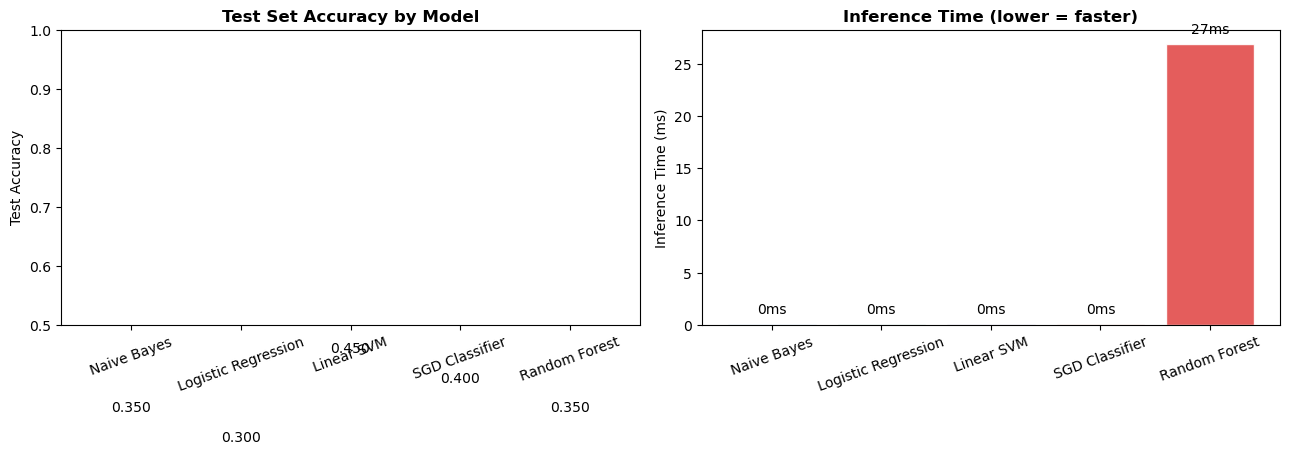

In [40]:
summary_data = []
for name in trained_models:
    summary_data.append({
        'Model'           : name,
        'CV Mean Acc'     : f"{cv_results[name].mean():.4f}",
        'CV Std'          : f"{cv_results[name].std():.4f}",
        'Test Accuracy'   : f"{test_results[name]['acc']:.4f}",
        'Train Time (s)'  : f"{train_times[name]:.2f}s",
        'Infer Time (ms)' : f"{timing_results[name]['avg_ms']:.1f}ms",
        'Per Doc (µs)'    : f"{timing_results[name]['per_doc']:.1f}µs"
    })

summary_df = pd.DataFrame(summary_data).set_index('Model')
print("\n📋 FINAL COMPARISON TABLE")
print("=" * 85)
print(summary_df.to_string())
print("=" * 85)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names_all = list(trained_models.keys())
test_accs = [test_results[n]['acc'] for n in names_all]
infer_ms  = [timing_results[n]['avg_ms'] for n in names_all]
colors    = ['#378ADD', '#1D9E75', '#534AB7', '#D85A30', '#E24B4A']

bars = axes[0].bar(names_all, test_accs, color=colors, edgecolor='white', alpha=0.9)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Set Accuracy by Model', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.003,
                 f'{v:.3f}', ha='center', fontsize=10)

bars2 = axes[1].bar(names_all, infer_ms, color=colors, edgecolor='white', alpha=0.9)
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('Inference Time (lower = faster)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(bars2, infer_ms):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1,
                 f'{v:.0f}ms', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## Predict on New Text
> Must apply the SAME cleaning + SAME vectorizer to any new comment.

In [ ]:
best_model = trained_models['Linear SVM']   # change to any model

new_comments = [
    "This product is absolutely amazing! Loved every bit of it.",
    "It was okay, nothing special, could be better.",
    "Terrible experience. Would never recommend this to anyone."
]

label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# Step 1: Apply the SAME cleaning pipeline
new_clean = [clean_text(c) for c in new_comments]

# Step 2: Transform using the SAME vectorizer (NOT fit_transform!)
new_vec = vectorizer.transform(new_clean)

# Step 3: Predict
preds = best_model.predict(new_vec)

print("Predictions on new comments:\n")
for raw, cleaned, pred in zip(new_comments, new_clean, preds):
    print(f"  Original : {raw}")
    print(f"  Cleaned  : {cleaned}")
    print(f"  Predicted: {label_map[pred]}\n")

---
##  Complete Pipeline Summary

| Step | What We Did | Key Rule |
|------|-------------|----------|
| 1 | Load & explore data | Check class balance and null values |
| 2 | Train/Test split FIRST | Never touch test data during preprocessing |
| 3 | Expand contractions | Do this BEFORE removing punctuation |
| 4 | Remove URLs | No signal for sentiment |
| 5 | Remove non-ASCII | Keeps only English text |
| 6 | Remove punctuation | Reduces noisy tokens |
| 7 | Normalise repeated chars | `reallly` → `really` |
| 8 | Lowercase | `Apple` = `apple` |
| 9 | Drop very short comments | < 3 words = no signal |
| 10 | BOW `fit_transform` on train | Learn vocabulary from train only |
| 11 | BOW `transform` on test | Apply learned vocabulary to test |
| 12 | 5-Fold CV | Reliable accuracy estimate |
| 13 | Train on full set | Maximise data |
| 14 | Benchmark inference time | Production speed matters |
| 15 | Evaluate on test set | True real-world accuracy |

### Which model to choose?
| Priority | Choose |
|---|---|
| Best accuracy | Linear SVM |
| Need probabilities | Logistic Regression |
| Millions of docs / streaming | SGD Classifier |
| Quick baseline | Naive Bayes |
| Mixed text + numeric features | Random Forest |